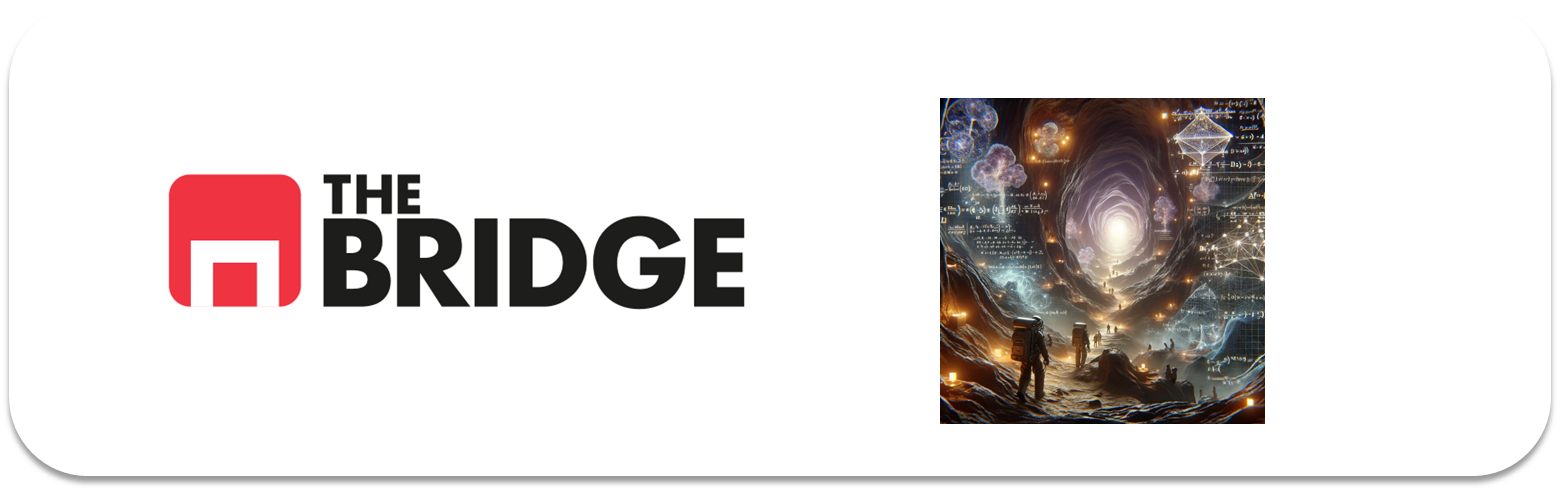

## PRACTICA OBLIGATORIA: **Introducción Keras**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Tratamiento de datos
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades de visualización del bootcamp (está en la misma carpeta que el notebook)
import bootcampviztools as bvt

# Métricas
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow import keras

# Semilla única para todo el notebook. set_random_seed fija de golpe las semillas
# de Python, NumPy y TensorFlow, así los entrenamientos son reproducibles.
SEED = 42
keras.utils.set_random_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

TensorFlow: 2.21.0 | Keras: 3.15.0


## Descripción de la práctica

En esta práctica el objetivo es jugar con el framework de [Keras](https://www.tensorflow.org/guide/keras) a partir de la construcción de un modelo DL sobre MLP para clasificar imagenes de ropa como camisetas, zapatos y zapatillas deportivas.

Vamos a utilizar el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles)

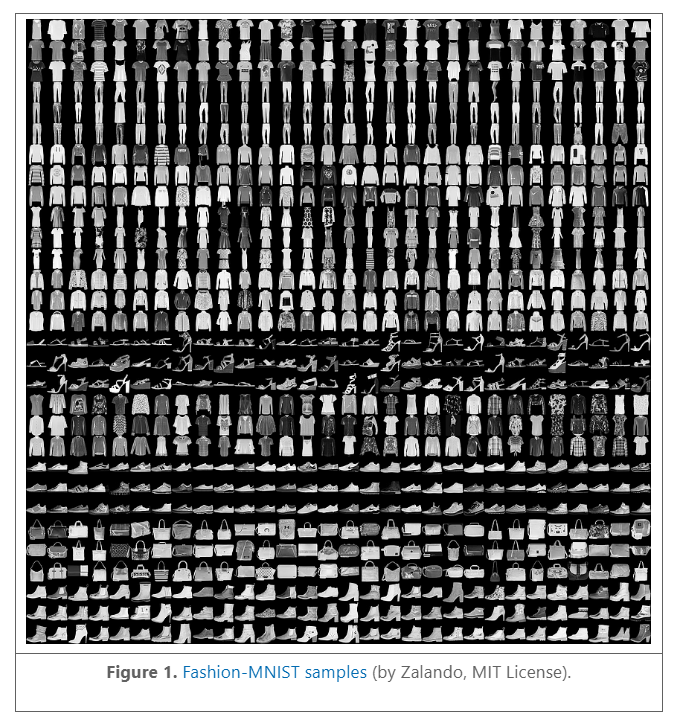

La *class* de ropa que la imagen representa:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset, es recomendable construirse una lista o un diccionario que permita mapear la clase a el tipo literal.

Se pide:

0. Cargar el dataset desde TensorFlow (tienes una celda ya proporcionada para hacerlo) y visualiza al menos 5 instancias, se recomienda crear una función que permita visualizar subsets de instancias con su etiqueta adecuada. 

1. Construir un modelo DL basado en MLP, es decir una red densa que clasifique las imágenes de ropa. No vas a necesitar más de 1 o 2 capas ocultas. Recuerda que es un problema de clasificación multiclase para configurar correctamente la capa de salida en número de neuronas y función de activiación. Ten en cuenta también que necesitarás utilizar una capa que aplane las imágenes o bien convertir el dataset por tu cuenta.

2. No crees un set de validación, especifica en el entrenamiento que emplee un 20% del dataset en validación. Además muestra gráficamente la evolución en el entrenamiento de la pérdida (loss) por un lado (del conjuto de train y del de validación) y la evolución de la métrica escogida (también de train  y de validación). Razona si es conveniente tener un "callback" de earlystopping, y, en cualquier caso, implementa uno.

3. Finalmente evalua contra test. Muestra el report de clasificación y haz un análisis de los resultados. Para ello, muestra algunas predicciones, el nivel de confianza y si era acertada o no, además muestra la matriz de confusión y analiza en que tipos se confunde más y con que otra clase lo confunde. 

Ejemplo del grafico de predicción más nivel de confianza:

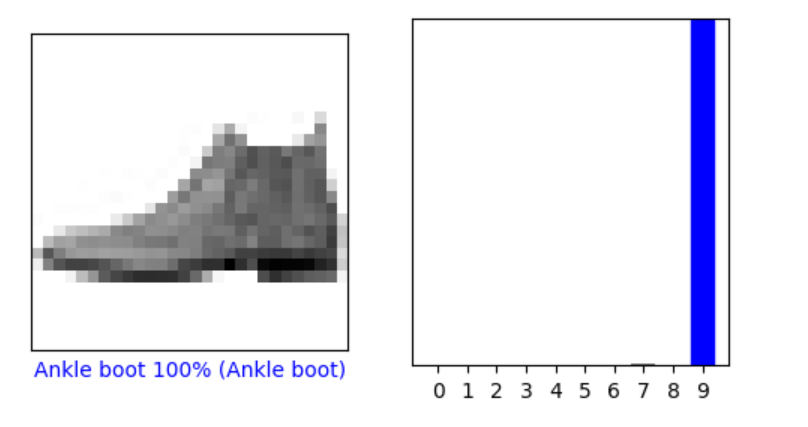

Fíjate que el gráfico de la derecha muestra la probabilidad por clase, de forma que cuanto más alta la probabilidad de la clase elegida más confianza podemos decir que tiene en el resultado. 

**EXTRA**: Como parte extra, obtén los errores de clasificación en los que la confianza del modelo sobre su clasificación errónea supere el 0.7 o 70% (es decir los errores en los que la probabilidad de la clase elegida, equivocadamente, fuera igual o superior a 0.7), de existir muéstralos y analiza si son de alguna clase específica.

```python

# Cargar FASHION_MNIST

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

```

---
## 1. Carga de los datos y primer vistazo

Cargamos Fashion MNIST directamente desde Keras. La primera vez que se ejecuta descarga el dataset
de internet (unos 30 MB) y lo deja cacheado, así que las siguientes veces es instantáneo.

In [2]:
# Cargar FASHION_MNIST (celda proporcionada en el enunciado)
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Train:", train_images.shape, "| etiquetas:", train_labels.shape)
print("Test :", test_images.shape, "| etiquetas:", test_labels.shape)

Train: (60000, 28, 28) | etiquetas: (60000,)
Test : (10000, 28, 28) | etiquetas: (10000,)


In [3]:
# Los nombres de las clases NO vienen en el dataset (solo tenemos números del 0 al 9),
# así que nos construimos la lista, tal y como recomienda el enunciado.
# El orden importa: la posición de la lista es el número de la etiqueta.
class_names = [
    "T-shirt/top",   # 0
    "Trouser",       # 1
    "Pullover",      # 2
    "Dress",         # 3
    "Coat",          # 4
    "Sandal",        # 5
    "Shirt",         # 6
    "Sneaker",       # 7
    "Bag",           # 8
    "Ankle boot",    # 9
]

print("Número de clases:", len(class_names))
for i, nombre in enumerate(class_names):
    print("  {} -> {}".format(i, nombre))

Número de clases: 10
  0 -> T-shirt/top
  1 -> Trouser
  2 -> Pullover
  3 -> Dress
  4 -> Coat
  5 -> Sandal
  6 -> Shirt
  7 -> Sneaker
  8 -> Bag
  9 -> Ankle boot


In [4]:
# ¿Cómo son los datos por dentro?
print("Tipo de dato :", train_images.dtype)
print("Valor mínimo :", train_images.min())
print("Valor máximo :", train_images.max())
print("Tamaño de cada imagen:", train_images[0].shape)

Tipo de dato : uint8
Valor mínimo : 0
Valor máximo : 255
Tamaño de cada imagen: (28, 28)


Cada imagen es una matriz de **28x28 números enteros entre 0 y 255** (la escala de grises de cada
píxel). Las etiquetas son enteros del 0 al 9.

Esto ya nos adelanta dos cosas que tendremos que hacer:

1. **Normalizar** los píxeles al rango 0-1 (como vimos en el workout con MNIST).
2. **Aplanar** las imágenes de 28x28 a un vector de 784, porque una capa `Dense` solo admite
   vectores 1D. Lo haremos con una capa `Flatten` dentro del propio modelo.

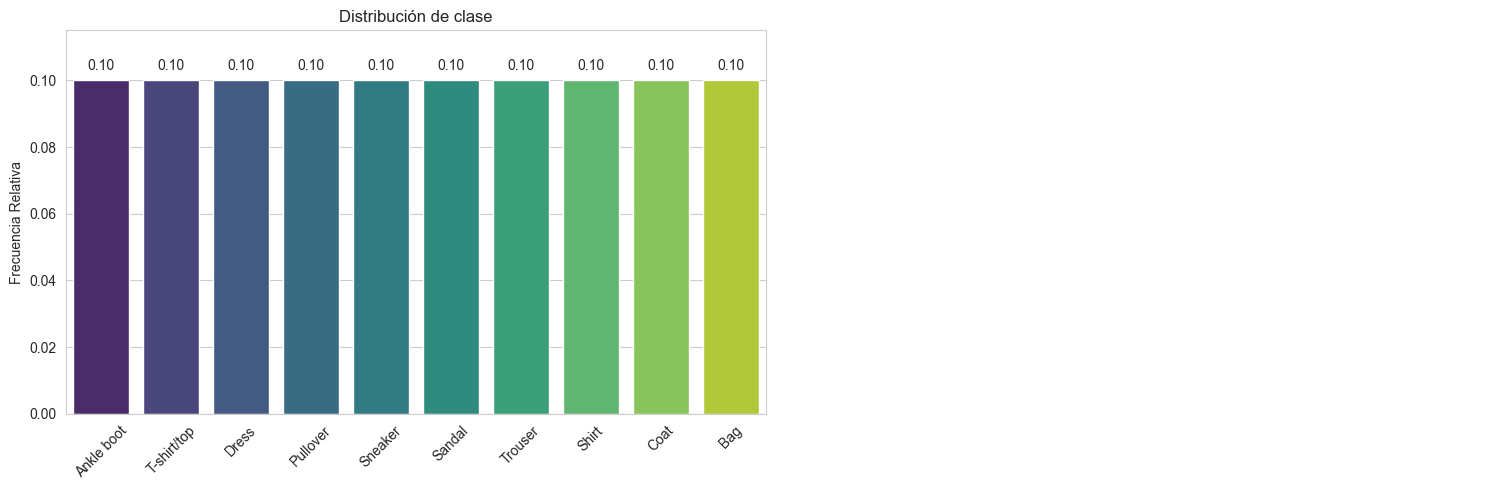

clase
Ankle boot     6000
T-shirt/top    6000
Dress          6000
Pullover       6000
Sneaker        6000
Sandal         6000
Trouser        6000
Shirt          6000
Coat           6000
Bag            6000
Name: count, dtype: int64


In [5]:
# Comprobamos el balanceo de las clases usando la función del bootcamp.
# Necesita un DataFrame, así que montamos uno con las etiquetas ya traducidas a texto.
df_etiquetas = pd.DataFrame({"clase": [class_names[i] for i in train_labels]})

bvt.pinta_distribucion_categoricas(df_etiquetas, ["clase"], relativa=True, mostrar_valores=True)

print(df_etiquetas["clase"].value_counts())

**El dataset está perfectamente balanceado:** exactamente **6.000 imágenes de cada una de las 10
clases** (un 10% cada una).

Esto nos simplifica la vida: con las clases perfectamente equilibradas, el **`accuracy` es una
métrica totalmente fiable** y será la que usemos. No hay riesgo de que el modelo haga trampas
apostando por una clase mayoritaria, porque no hay ninguna.

---
## 2. Visualización de instancias

El enunciado pide visualizar al menos 5 instancias y recomienda crear una función reutilizable, así
que hacemos una que muestre cualquier subconjunto de imágenes con su etiqueta.

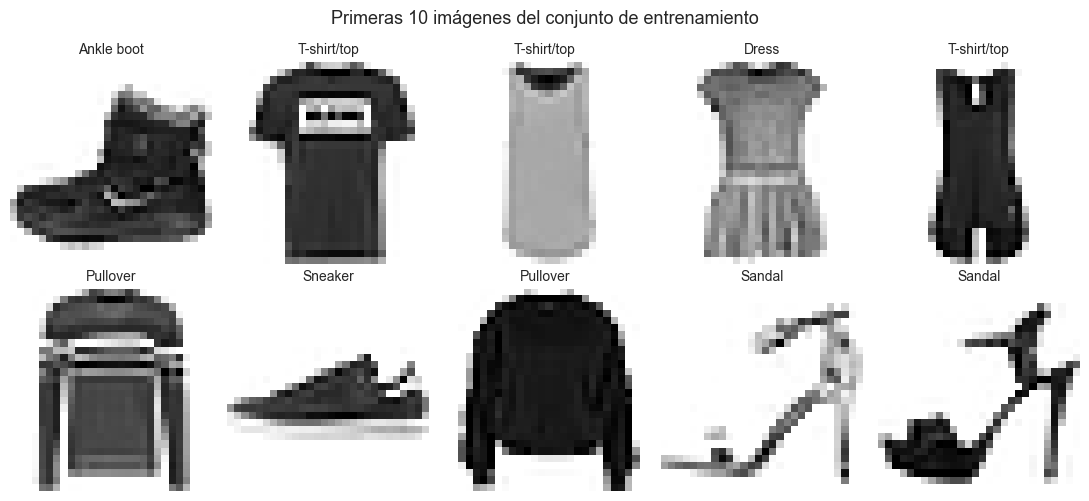

In [6]:
def muestra_imagenes(imagenes, etiquetas, indices, titulo=""):
    """
    Muestra un conjunto de imágenes con su etiqueta correspondiente.

    Argumentos:
        imagenes (np.array): array de imágenes (n, 28, 28).
        etiquetas (np.array): array con el número de clase de cada imagen.
        indices (list): posiciones de las imágenes que queremos mostrar.
        titulo (str): título general de la figura.
    """
    n = len(indices)
    columnas = 5
    filas = int(np.ceil(n / columnas))

    plt.figure(figsize=(2.2 * columnas, 2.6 * filas))

    for posicion, indice in enumerate(indices):
        plt.subplot(filas, columnas, posicion + 1)
        # cmap="binary" pinta la imagen en blanco y negro
        plt.imshow(imagenes[indice], cmap="binary")
        plt.title(class_names[etiquetas[indice]], fontsize=10)
        plt.axis("off")

    if titulo:
        plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


# Mostramos las 10 primeras imágenes del train
muestra_imagenes(train_images, train_labels, indices=range(10),
                 titulo="Primeras 10 imágenes del conjunto de entrenamiento")

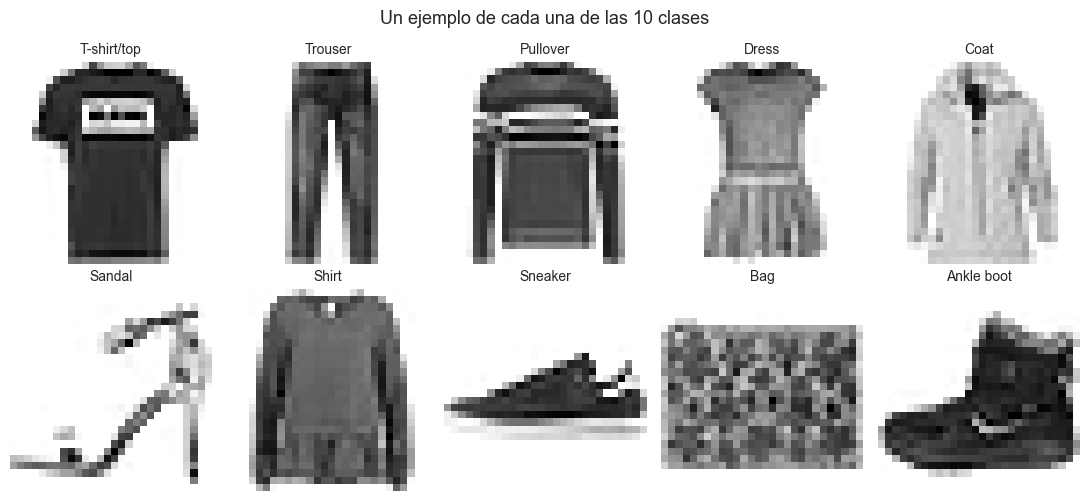

In [7]:
# Mostramos también un ejemplo de CADA clase, para ver con qué estamos trabajando
indices_una_por_clase = [np.where(train_labels == c)[0][0] for c in range(10)]

muestra_imagenes(train_images, train_labels, indices=indices_una_por_clase,
                 titulo="Un ejemplo de cada una de las 10 clases")

**Un detalle importante que se ve a simple vista:** varias clases son **muy parecidas entre sí**.
`T-shirt/top`, `Pullover`, `Coat` y `Shirt` son las cuatro prendas de torso y, a 28x28 píxeles en
escala de grises, se distinguen con dificultad incluso a ojo.

Anotamos esta sospecha: **es muy probable que el modelo se confunda justo entre esas clases**. Lo
comprobaremos al final con la matriz de confusión.

---
## 3. Preprocesado

Solo necesitamos normalizar. Como sabemos que los píxeles van de 0 a 255, dividir entre 255 equivale
a aplicar un `MinMaxScaler` y nos deja todo en el rango 0-1. Es el mismo truco del workout.

El aplanado de 28x28 a 784 **no lo hacemos aquí**: lo resolverá la capa `Flatten` dentro del modelo,
que es más cómodo porque así el modelo acepta directamente las imágenes tal cual.

In [8]:
# Normalizamos dividiendo entre 255 (el valor máximo de un píxel)
train_images_norm = train_images / 255.0
test_images_norm = test_images / 255.0

print("Rango tras normalizar -> mín:", train_images_norm.min(), "| máx:", train_images_norm.max())

Rango tras normalizar -> mín: 0.0 | máx: 1.0


---
## 4. Construcción del modelo

Montamos un MLP (red densa) siguiendo el enunciado: **una sola capa oculta** es suficiente.

Las decisiones de la arquitectura, una por una:

| Capa | Configuración | Por qué |
|---|---|---|
| `Flatten` | entrada 28x28 | Convierte la imagen 2D en un vector de 784. No tiene parámetros, solo reordena |
| `Dense` oculta | 128 neuronas, `relu` | Un valor estándar para este problema. ReLU es la activación por defecto en capas ocultas |
| `Dense` salida | **10** neuronas, **`softmax`** | 10 porque hay 10 clases; softmax porque es clasificación **multiclase** y queremos probabilidades que sumen 1 |

Y para el `compile`:

- **`loss='sparse_categorical_crossentropy'`**: es multiclase, y usamos la versión **sparse** porque
  nuestras etiquetas son **enteros del 0 al 9**. Si estuviesen en one-hot usaríamos
  `categorical_crossentropy` (la fórmula es la misma, solo cambia el formato de las etiquetas).
- **`optimizer='adam'`**: el estándar actual, funciona bien sin tener que tocar el learning rate.
- **`metrics=['accuracy']`**: la métrica que reportamos. Recuerda que **no se puede optimizar
  directamente** (no es derivable), por eso optimizamos la cross-entropy y medimos el accuracy.

In [9]:
def construye_modelo():
    """
    Crea y compila el MLP de clasificación de imágenes.

    Lo metemos en una función para poder reconstruirlo desde cero si hiciera falta
    (si reutilizásemos un modelo ya entrenado, fit() continuaría donde lo dejó).

    Retorna:
        keras.Sequential: el modelo ya compilado.
    """
    modelo = keras.Sequential([
        # Aplana la imagen de 28x28 en un vector de 784 valores
        keras.layers.Flatten(input_shape=(28, 28)),
        # Capa oculta
        keras.layers.Dense(128, activation="relu"),
        # Capa de salida: 10 neuronas (una por clase) con softmax
        keras.layers.Dense(10, activation="softmax"),
    ])

    modelo.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


keras.utils.set_random_seed(SEED)
model = construye_modelo()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

En el `summary()` se ve muy bien lo que comentábamos:

- **`Flatten` tiene 0 parámetros**: no aprende nada, solo cambia la forma de los datos.
- La capa oculta tiene **100.480 parámetros** (784 x 128 + 128 bias).
- La de salida tiene **1.290** (128 x 10 + 10 bias).

En total unos **101.770 parámetros** para entrenar. Parecen muchísimos, pero tenemos 60.000 imágenes,
que es una cantidad de datos razonable para una red de este tamaño. (Compáralo con la práctica del
Titanic de la unidad anterior: allí teníamos más pesos que filas de datos, y por eso sobreajustaba
tanto.)

---
## 5. Entrenamiento

El enunciado pide **no crear un set de validación aparte**, sino usar `validation_split=0.2` dentro
del `fit`. Con eso Keras reserva el 20% de las 60.000 imágenes (12.000) para validar y entrena con
las 48.000 restantes.

### ¿Conviene un callback de EarlyStopping? Razonamiento

**Sí, claramente conviene**, por dos motivos:

1. **No sabemos cuántas epochs hacen falta.** Si ponemos pocas nos quedamos cortos (underfitting) y
   si ponemos muchas sobreentrenamos. El EarlyStopping resuelve el dilema: ponemos un número alto de
   epochs y dejamos que él decida cuándo parar.
2. **Este modelo va a sobreajustar casi seguro.** Tenemos ~102.000 parámetros y una red densa que,
   al aplanar la imagen, pierde toda la información espacial y tiende a memorizar píxeles concretos.
   Es de esperar que la pérdida de validación empiece a subir mientras la de train sigue bajando.

Lo configuramos así:

- `monitor="val_loss"` → vigilamos la pérdida de **validación**, que es la que nos dice si generaliza.
- `patience=3` → toleramos 3 epochs sin mejora antes de cortar (le damos margen para que no pare por
  una fluctuación puntual).
- `restore_best_weights=True` → **imprescindible**: al parar nos quedamos con los pesos de la mejor
  epoch, no con los de la última (que ya son peores).

In [10]:
# Callback de EarlyStopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

# Ponemos un número alto de epochs a propósito: el callback decidirá cuándo parar
history = model.fit(
    train_images_norm,
    train_labels,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=2,          # una línea por epoch, para poder seguir el entrenamiento
)

epochs_hechas = len(history.history["loss"])
print("\nEl entrenamiento se detuvo en la epoch {} de 30".format(epochs_hechas))

Epoch 1/30


1500/1500 - 4s - 2ms/step - accuracy: 0.8186 - loss: 0.5173 - val_accuracy: 0.8438 - val_loss: 0.4392


Epoch 2/30


1500/1500 - 3s - 2ms/step - accuracy: 0.8614 - loss: 0.3881 - val_accuracy: 0.8547 - val_loss: 0.4019


Epoch 3/30


...

Epoch 8/30


1500/1500 - 3s - 2ms/step - accuracy: 0.9047 - loss: 0.2564 - val_accuracy: 0.8811 - val_loss: 0.3438


Epoch 9/30


1500/1500 - 3s - 2ms/step - accuracy: 0.9096 - loss: 0.2451 - val_accuracy: 0.8838 - val_loss: 0.3450



El entrenamiento se detuvo en la epoch 9 de 30


---
## 6. Evolución del entrenamiento

Pintamos por separado la **pérdida** (train y validación) y la **métrica elegida, el accuracy**
(train y validación), tal y como pide el enunciado.

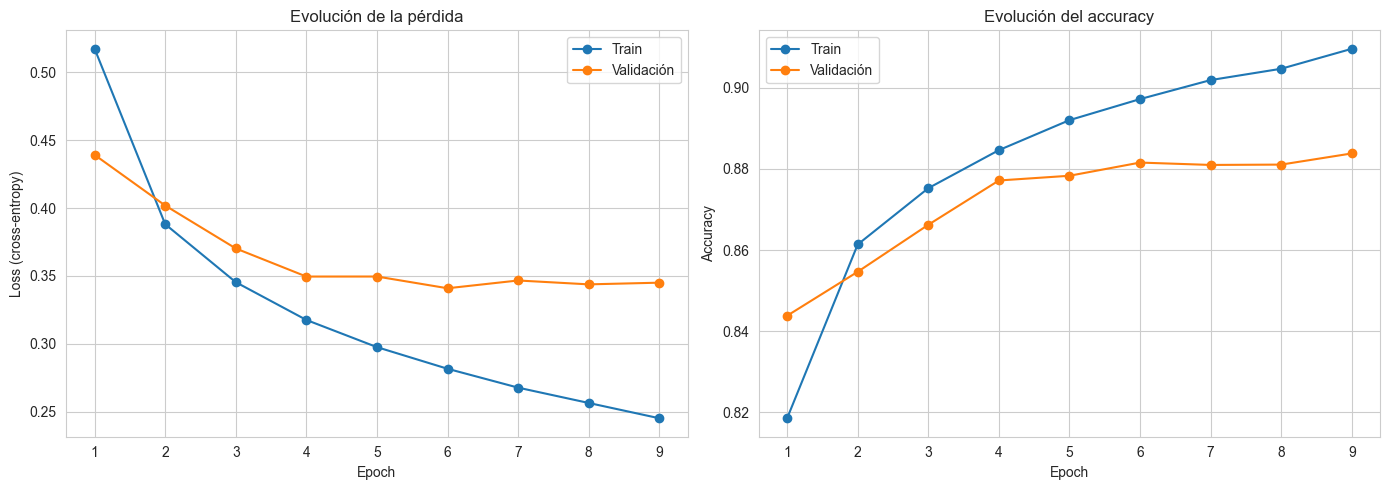

,accuracy,loss,val_accuracy,val_loss,epoch
0,0.8186,0.5173,0.8438,0.4392,1
1,0.8614,0.3881,0.8547,0.4019,2
2,0.8753,0.3454,0.8662,0.3702,3
3,0.8846,0.3176,0.8772,0.3495,4
4,0.8920,0.2975,0.8783,0.3496,5
5,0.8972,0.2816,0.8816,0.3409,6
6,0.9019,0.2677,0.8810,0.3466,7
7,0.9047,0.2564,0.8811,0.3438,8
8,0.9096,0.2451,0.8838,0.3450,9


In [11]:
hist = pd.DataFrame(history.history)
hist["epoch"] = hist.index + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: pérdida (lo que realmente se minimiza)
axes[0].plot(hist["epoch"], hist["loss"], marker="o", label="Train")
axes[0].plot(hist["epoch"], hist["val_loss"], marker="o", label="Validación")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (cross-entropy)")
axes[0].set_title("Evolución de la pérdida")
axes[0].legend()

# Gráfica 2: accuracy (la métrica que reportamos)
axes[1].plot(hist["epoch"], hist["accuracy"], marker="o", label="Train")
axes[1].plot(hist["epoch"], hist["val_accuracy"], marker="o", label="Validación")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Evolución del accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

hist.round(4)

### Comentario de las curvas

**El EarlyStopping ha demostrado que era necesario.** El entrenamiento se detuvo en la **epoch 9 de
30**, y mirando las curvas se entiende perfectamente por qué:

- La **pérdida de validación tocó su mínimo en la epoch 6** (0,341) y a partir de ahí se quedó
  plana e incluso subió ligeramente (0,347 / 0,344 / 0,345).
- Mientras tanto, la **pérdida de train siguió bajando sin parar** (de 0,282 a 0,245).

Esa **separación entre las dos curvas es la firma del overfitting**: el modelo ya no está aprendiendo
patrones generalizables, está memorizando el conjunto de entrenamiento. Se ve igual en el accuracy:
termina con un **90,96% en train frente a un 88,38% en validación**, una diferencia de unos 2,6
puntos que no hacía más que crecer.

Gracias a `restore_best_weights=True` **no nos quedamos con los pesos de la epoch 9, sino con los de
la 6**, que son los que mejor generalizaban.

> **Curiosidad de la primera epoch:** el accuracy de validación (84,38%) es *mayor* que el de train
> (81,86%). No es un error. El accuracy de train es la media de toda la epoch, incluyendo el
> principio, cuando el modelo aún era muy malo; el de validación se mide al final, cuando ya ha
> aprendido durante toda la epoch.

---
## 7. Evaluación contra test

Ahora sí, evaluamos con las 10.000 imágenes de test, que el modelo no ha visto en ningún momento.

In [12]:
test_loss, test_accuracy = model.evaluate(test_images_norm, test_labels, verbose=0)

print("Resultados sobre el conjunto de TEST")
print("=" * 40)
print("Loss     : {:.4f}".format(test_loss))
print("Accuracy : {:.4f}  ({:.2f}%)".format(test_accuracy, test_accuracy * 100))

Resultados sobre el conjunto de TEST
Loss     : 0.3673
Accuracy : 0.8713  (87.13%)


In [13]:
# Predicciones sobre test.
# Como la última capa es softmax, predict() devuelve las PROBABILIDADES de cada clase:
# un array de (10000, 10) donde cada fila suma 1.
y_prob = model.predict(test_images_norm, verbose=0)

# La clase predicha es la de mayor probabilidad
y_pred = y_prob.argmax(axis=1)

# Y la confianza del modelo es esa probabilidad máxima
confianza = y_prob.max(axis=1)

print("Forma de las probabilidades:", y_prob.shape)
print("\nEjemplo, probabilidades de la primera imagen de test:")
for i, nombre in enumerate(class_names):
    print("  {:12s}: {:.4f}".format(nombre, y_prob[0][i]))
print("\nSuma de las probabilidades: {:.4f}  <- softmax siempre suma 1".format(y_prob[0].sum()))

Forma de las probabilidades: (10000, 10)

Ejemplo, probabilidades de la primera imagen de test:
  T-shirt/top : 0.0000
  Trouser     : 0.0000
  Pullover    : 0.0000
  Dress       : 0.0000
  Coat        : 0.0000
  Sandal      : 0.0059
  Shirt       : 0.0001
  Sneaker     : 0.1275
  Bag         : 0.0001
  Ankle boot  : 0.8664

Suma de las probabilidades: 1.0000  <- softmax siempre suma 1


In [14]:
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(test_labels, y_pred, target_names=class_names, digits=3))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/top      0.848     0.794     0.820      1000
     Trouser      0.994     0.961     0.977      1000
    Pullover      0.801     0.768     0.784      1000
       Dress      0.821     0.924     0.869      1000
        Coat      0.797     0.805     0.801      1000
      Sandal      0.986     0.934     0.959      1000
       Shirt      0.688     0.672     0.680      1000
     Sneaker      0.868     0.986     0.923      1000
         Bag      0.950     0.973     0.961      1000
  Ankle boot      0.976     0.896     0.934      1000

    accuracy                          0.871     10000
   macro avg      0.873     0.871     0.871     10000
weighted avg      0.873     0.871     0.871     10000



### Análisis del classification report

**Accuracy global: 87,13%.** Para una red densa sencilla con una sola capa oculta y 10 clases, es un
resultado muy digno (un modelo aleatorio acertaría un 10%).

Pero el dato interesante no es la media, sino **lo desigual que es el rendimiento entre clases**:

| Van muy bien (F1 > 0,92) | Van mal (F1 < 0,83) |
|---|---|
| Trouser (0,977), Bag (0,961), Sandal (0,959), Sneaker (0,923), Ankle boot (0,934) | **Shirt (0,680)**, Pullover (0,784), Coat (0,801), T-shirt/top (0,820) |

**Se confirma exactamente la sospecha que anotamos al ver las imágenes:** las cuatro clases que peor
van son justo **las cuatro prendas de torso** (`Shirt`, `Pullover`, `Coat`, `T-shirt/top`), mientras
que las que tienen una silueta inconfundible (pantalón, bolso, calzado) van estupendamente.

La peor con diferencia es **`Shirt`, con un F1 de solo 0,680**: el modelo solo detecta el 67,2% de
las camisas. Tiene sentido, porque una camisa es visualmente "el punto medio" entre una camiseta, un
jersey y un abrigo, así que es la que más se solapa con todas las demás.

---
## 8. Predicciones individuales con su nivel de confianza

Reproducimos el gráfico que muestra el enunciado: a la izquierda la imagen con la predicción, y a la
derecha un gráfico de barras con la probabilidad que el modelo da a cada una de las 10 clases.

El código de color es el habitual: **azul si acierta, rojo si falla**.

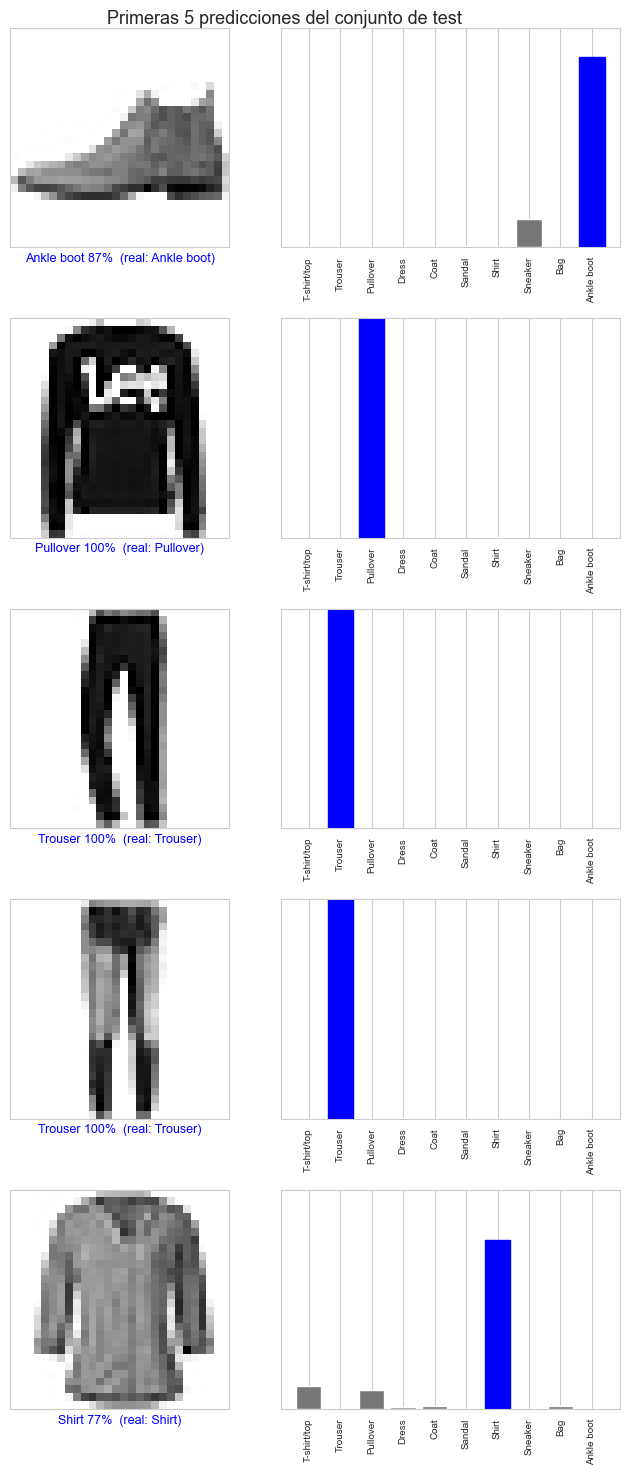

In [15]:
def pinta_imagen(indice, y_prob, etiquetas_reales, imagenes):
    """
    Pinta una imagen con la predicción del modelo, su confianza y la etiqueta real.
    El texto sale en azul si la predicción es correcta y en rojo si es errónea.
    """
    probabilidades = y_prob[indice]
    etiqueta_real = etiquetas_reales[indice]
    etiqueta_pred = probabilidades.argmax()

    plt.imshow(imagenes[indice], cmap="binary")
    plt.xticks([])
    plt.yticks([])

    color = "blue" if etiqueta_pred == etiqueta_real else "red"
    plt.xlabel("{} {:2.0f}%  (real: {})".format(
        class_names[etiqueta_pred],
        100 * probabilidades.max(),
        class_names[etiqueta_real],
    ), color=color, fontsize=9)


def pinta_barras_probabilidad(indice, y_prob, etiquetas_reales):
    """
    Pinta un gráfico de barras con la probabilidad asignada a cada clase.
    En rojo la clase predicha y en azul la real (si acierta, se superponen y queda azul).
    """
    probabilidades = y_prob[indice]
    etiqueta_real = etiquetas_reales[indice]
    etiqueta_pred = probabilidades.argmax()

    barras = plt.bar(range(10), probabilidades, color="#777777")
    plt.xticks(range(10), class_names, rotation=90, fontsize=7)
    plt.ylim([0, 1])
    plt.yticks([])

    barras[etiqueta_pred].set_color("red")
    barras[etiqueta_real].set_color("blue")


def muestra_predicciones(indices, y_prob, etiquetas_reales, imagenes, titulo=""):
    """
    Muestra varias predicciones, cada una con su imagen y su gráfico de confianza al lado.
    """
    filas = len(indices)
    plt.figure(figsize=(7, 3 * filas))

    for posicion, indice in enumerate(indices):
        plt.subplot(filas, 2, 2 * posicion + 1)
        pinta_imagen(indice, y_prob, etiquetas_reales, imagenes)

        plt.subplot(filas, 2, 2 * posicion + 2)
        pinta_barras_probabilidad(indice, y_prob, etiquetas_reales)

    if titulo:
        plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


# Mostramos las 5 primeras predicciones de test
muestra_predicciones(range(5), y_prob, test_labels, test_images,
                     titulo="Primeras 5 predicciones del conjunto de test")

Total de errores en test: 1287 de 10000 (12.87%)


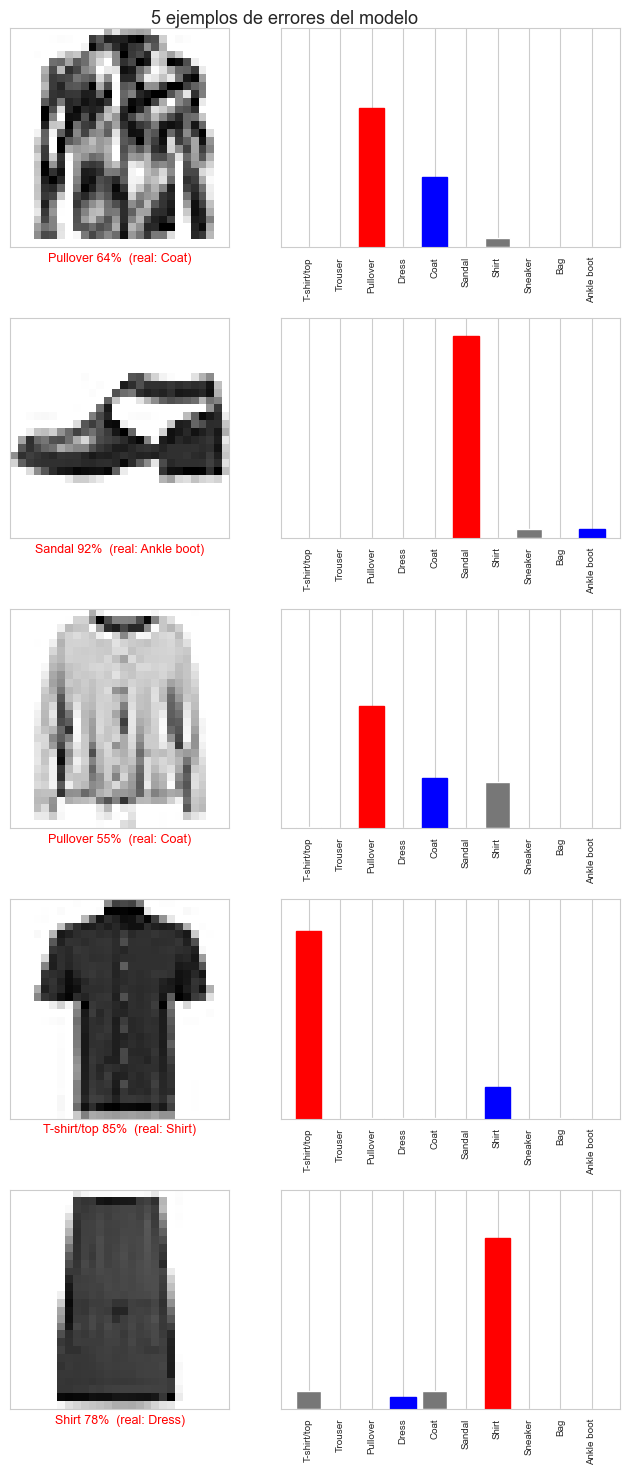

In [16]:
# Ahora unos cuantos ERRORES, que es de donde más se aprende
indices_errores = np.where(y_pred != test_labels)[0]
print("Total de errores en test: {} de {} ({:.2f}%)".format(
    len(indices_errores), len(test_labels), 100 * len(indices_errores) / len(test_labels)))

muestra_predicciones(indices_errores[:5], y_prob, test_labels, test_images,
                     titulo="5 ejemplos de errores del modelo")

---
## 9. Matriz de confusión

Vamos a ver **con qué clases se confunde el modelo**, que es lo que pide el enunciado.

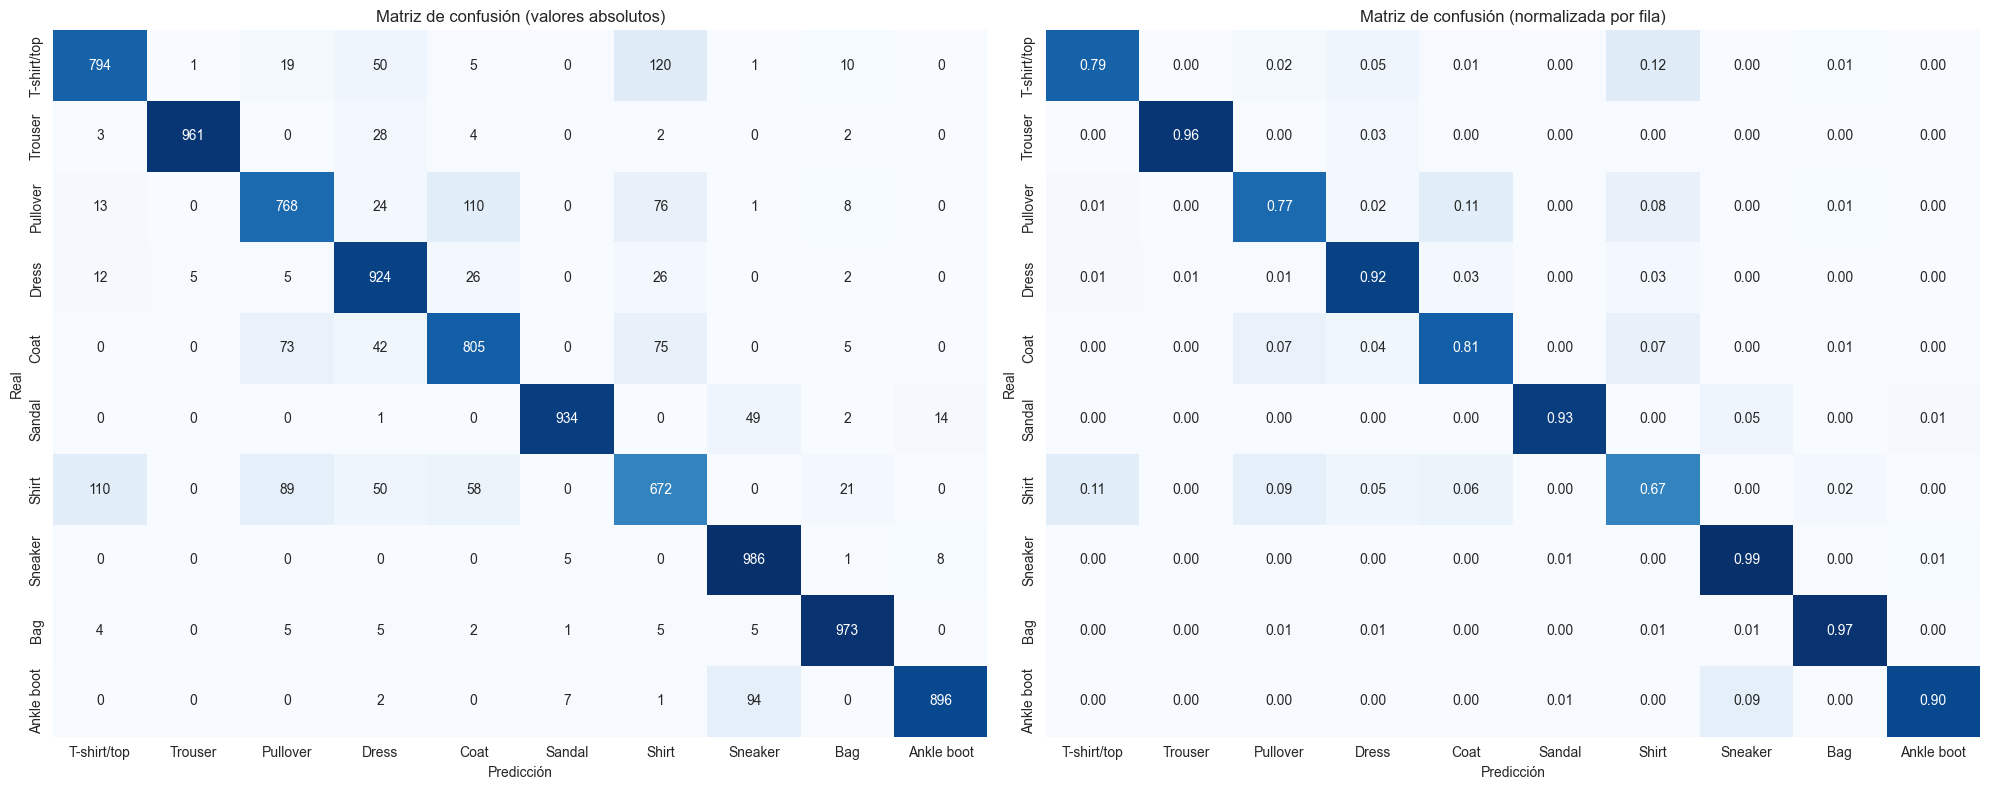

In [17]:
cm = confusion_matrix(test_labels, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz en valores absolutos
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de confusión (valores absolutos)")

# Matriz normalizada por fila (qué % de cada clase real va a cada predicción)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de confusión (normalizada por fila)")

plt.tight_layout()
plt.show()

In [18]:
# Para analizarlo con números, sacamos las confusiones más frecuentes.
# Ponemos la diagonal a cero porque los aciertos no nos interesan aquí.
cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

confusiones = []
for real in range(10):
    for predicha in range(10):
        if cm_sin_diagonal[real, predicha] > 0:
            confusiones.append({
                "clase_real": class_names[real],
                "predicha_como": class_names[predicha],
                "n_errores": cm_sin_diagonal[real, predicha],
                "% de la clase real": round(100 * cm_sin_diagonal[real, predicha] / cm[real].sum(), 2),
            })

df_confusiones = pd.DataFrame(confusiones).sort_values("n_errores", ascending=False)

print("LAS 10 CONFUSIONES MÁS FRECUENTES")
print("=" * 60)
print(df_confusiones.head(10).to_string(index=False))

LAS 10 CONFUSIONES MÁS FRECUENTES
 clase_real predicha_como  n_errores  % de la clase real
T-shirt/top         Shirt        120                12.0
   Pullover          Coat        110                11.0
      Shirt   T-shirt/top        110                11.0
 Ankle boot       Sneaker         94                 9.4
      Shirt      Pullover         89                 8.9
   Pullover         Shirt         76                 7.6
       Coat         Shirt         75                 7.5
       Coat      Pullover         73                 7.3
      Shirt          Coat         58                 5.8
T-shirt/top         Dress         50                 5.0


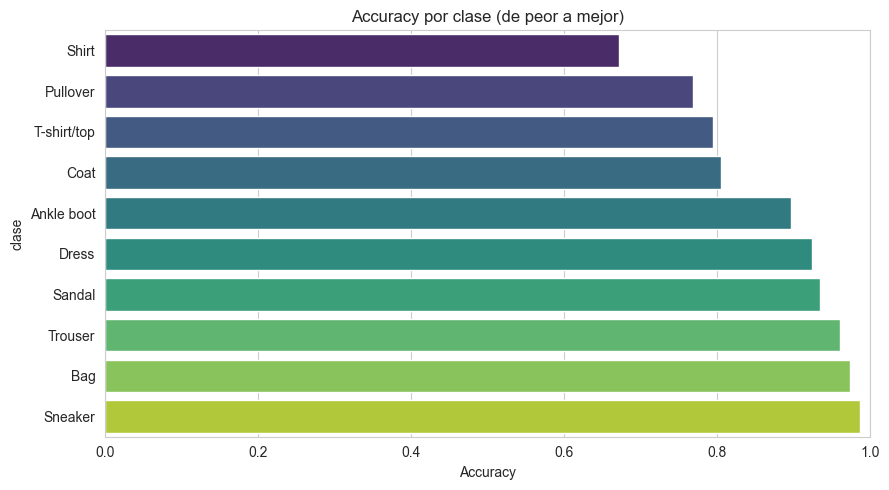

      clase  aciertos  total  accuracy
      Shirt       672   1000     0.672
   Pullover       768   1000     0.768
T-shirt/top       794   1000     0.794
       Coat       805   1000     0.805
 Ankle boot       896   1000     0.896
      Dress       924   1000     0.924
     Sandal       934   1000     0.934
    Trouser       961   1000     0.961
        Bag       973   1000     0.973
    Sneaker       986   1000     0.986


In [19]:
# ¿Qué clase se le da peor al modelo? Miramos el accuracy por clase
accuracy_por_clase = pd.DataFrame({
    "clase": class_names,
    "aciertos": cm.diagonal(),
    "total": cm.sum(axis=1),
})
accuracy_por_clase["accuracy"] = (accuracy_por_clase["aciertos"] / accuracy_por_clase["total"]).round(4)
accuracy_por_clase = accuracy_por_clase.sort_values("accuracy")

plt.figure(figsize=(9, 5))
sns.barplot(data=accuracy_por_clase, x="accuracy", y="clase",
            hue="clase", palette="viridis", legend=False)
plt.title("Accuracy por clase (de peor a mejor)")
plt.xlabel("Accuracy")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print(accuracy_por_clase.to_string(index=False))

### Análisis de la matriz de confusión

Los errores **no están repartidos al azar**: se concentran en dos grupos muy claros.

**Grupo 1 — Las prendas de torso (donde está casi todo el problema):**

| Confusión | Errores | % de la clase |
|---|---|---|
| T-shirt/top → **Shirt** | 120 | 12,0% |
| Pullover → **Coat** | 110 | 11,0% |
| Shirt → **T-shirt/top** | 110 | 11,0% |
| Shirt → **Pullover** | 89 | 8,9% |
| Pullover → **Shirt** | 76 | 7,6% |
| Coat → **Shirt** | 75 | 7,5% |
| Coat → **Pullover** | 73 | 7,3% |

Fíjate en que **las confusiones son mutuas**: T-shirt se confunde con Shirt y Shirt con T-shirt;
Pullover con Coat y Coat con Pullover. Es un **bloque de cuatro clases que se mezclan entre sí**, y
si sumamos todos esos errores nos sale la mayor parte de los 1.287 fallos totales.

**Grupo 2 — El calzado:**

- `Ankle boot` → `Sneaker`: **94 errores (9,4%)**

También razonable: una bota baja y una zapatilla tienen una silueta muy parecida a 28x28 píxeles.

**La conclusión importante:** el modelo **no está fallando de forma aleatoria, está fallando de forma
lógica**. Confunde exactamente las cosas que un humano también confundiría a esa resolución. Nunca
predice "bolso" cuando ve una sandalia ni "pantalón" cuando ve un abrigo: los errores respetan la
semejanza visual.

---
## 10. EXTRA: errores con una confianza superior al 70%

El enunciado propone buscar los casos en los que el modelo **se equivoca pero además está muy seguro
de sí mismo** (confianza >= 0,7). Son los errores más preocupantes: si el modelo dudase, al menos
podríamos detectarlo y mandar el caso a revisión manual; pero si falla con un 95% de confianza, no
hay forma de saber que se ha equivocado.

In [20]:
# Nos quedamos con los errores en los que la confianza fue >= 0.7
errores_confiados = [i for i in indices_errores if confianza[i] >= 0.7]

print("Errores totales                        : {}".format(len(indices_errores)))
print("Errores con confianza >= 0.7           : {}".format(len(errores_confiados)))
print("Porcentaje sobre el total de errores   : {:.1f}%".format(
    100 * len(errores_confiados) / len(indices_errores)))
print("Porcentaje sobre el total de test      : {:.2f}%".format(
    100 * len(errores_confiados) / len(test_labels)))

Errores totales                        : 1287
Errores con confianza >= 0.7           : 558
Porcentaje sobre el total de errores   : 43.4%
Porcentaje sobre el total de test      : 5.58%


In [21]:
# ¿Estos errores tan confiados se concentran en alguna clase concreta?
df_errores_confiados = pd.DataFrame({
    "clase_real": [class_names[test_labels[i]] for i in errores_confiados],
    "predicha_como": [class_names[y_pred[i]] for i in errores_confiados],
    "confianza": [confianza[i] for i in errores_confiados],
})

print("ERRORES CONFIADOS AGRUPADOS POR CLASE REAL")
print("=" * 50)
print(df_errores_confiados["clase_real"].value_counts().to_string())
print()
print("PAREJAS (real -> predicha) MÁS FRECUENTES")
print("=" * 50)
print(df_errores_confiados.groupby(["clase_real", "predicha_como"]).size()
      .sort_values(ascending=False).head(10).to_string())
print()
print("Confianza media en estos errores: {:.3f}".format(df_errores_confiados["confianza"].mean()))
print("Confianza máxima                : {:.3f}".format(df_errores_confiados["confianza"].max()))

ERRORES CONFIADOS AGRUPADOS POR CLASE REAL
clase_real
Shirt          145
Coat            88
Pullover        80
Ankle boot      70
T-shirt/top     66
Sandal          45
Trouser         24
Dress           21
Bag             12
Sneaker          7

PAREJAS (real -> predicha) MÁS FRECUENTES
clase_real   predicha_como
Ankle boot   Sneaker          64
Shirt        T-shirt/top      52
Pullover     Coat             42
Coat         Pullover         39
Sandal       Sneaker          34
Shirt        Pullover         34
T-shirt/top  Shirt            34
Shirt        Coat             30
Coat         Shirt            26
             Dress            21

Confianza media en estos errores: 0.854
Confianza máxima                : 1.000


### Análisis del EXTRA: los errores "confiados"

**Los números:** de los 1.287 errores totales, **558 (el 43,4%) se cometieron con una confianza igual
o superior al 70%**. Eso es un 5,58% de todo el conjunto de test. La confianza media en esos errores
fue del **85,4%**, y hubo casos con confianza del **100%**.

**¿Se concentran en alguna clase específica? Sí, y son las mismas de siempre:**

| Clase real | Errores confiados |
|---|---|
| **Shirt** | 145 |
| Coat | 88 |
| Pullover | 80 |
| Ankle boot | 70 |
| T-shirt/top | 66 |
| ... | ... |
| Sneaker | 7 |

Las cinco primeras posiciones las ocupan **las cuatro prendas de torso más la bota**, es decir,
exactamente los dos grupos problemáticos que ya habíamos identificado. En el otro extremo, `Sneaker`
solo tiene 7 errores confiados y `Bag` 12: cuando el modelo ve algo con forma inconfundible, acierta
y además acierta con razón.

**Por qué esto importa:** un error con un 95% de confianza es **mucho peor que un error dudando**. Si
el modelo dudase (por ejemplo, 45% camisa y 40% camiseta), podríamos poner un umbral y mandar esos
casos a revisión manual. Pero cuando falla con total seguridad, **no hay ninguna señal que nos
permita detectarlo automáticamente**. Es decir, el modelo no solo se equivoca: además no "sabe" que
se está equivocando.

Este fenómeno tiene nombre, se llama **mala calibración**, y es muy típico de las redes neuronales
entrenadas con cross-entropy: tienden a ser **más seguras de lo que deberían**. Existen técnicas para
corregirlo (*temperature scaling*, por ejemplo), pero eso ya se sale del alcance de esta práctica.

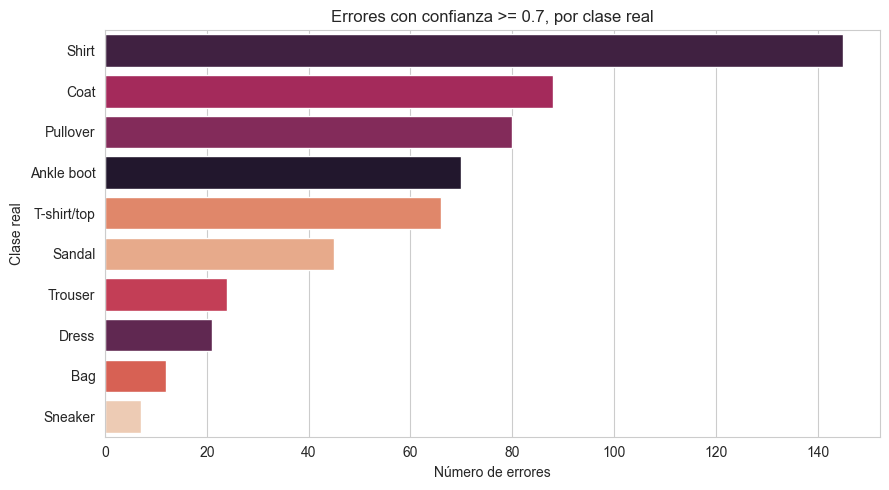

In [22]:
# Lo visualizamos: distribución de estos errores por clase real
plt.figure(figsize=(9, 5))
orden = df_errores_confiados["clase_real"].value_counts().index
sns.countplot(data=df_errores_confiados, y="clase_real", order=orden,
              hue="clase_real", palette="rocket", legend=False)
plt.title("Errores con confianza >= 0.7, por clase real")
plt.xlabel("Número de errores")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

Los 5 errores con mayor confianza:
  Real: Sandal       -> Predicho: Bag          (confianza 100.0%)
  Real: T-shirt/top  -> Predicho: Dress        (confianza 100.0%)
  Real: Ankle boot   -> Predicho: Sandal       (confianza 100.0%)
  Real: Ankle boot   -> Predicho: Shirt        (confianza 99.9%)
  Real: Ankle boot   -> Predicho: Sneaker      (confianza 99.9%)


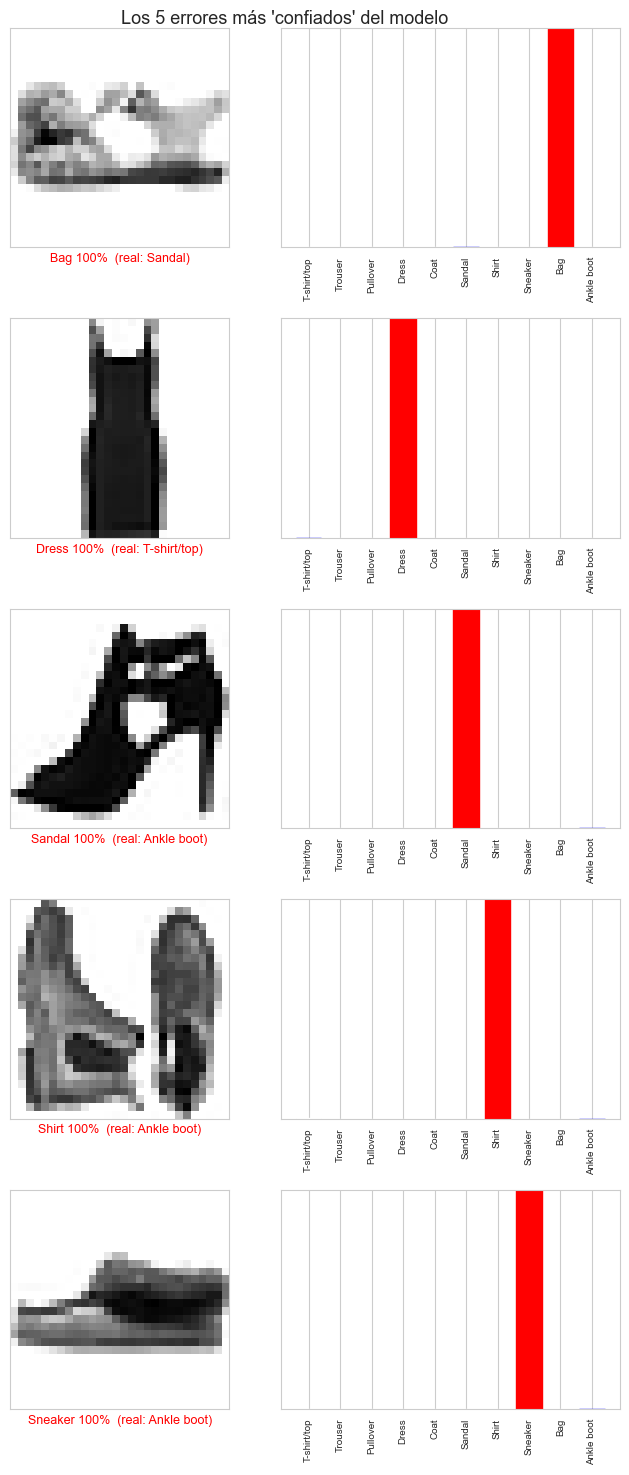

In [23]:
# Mostramos los 5 errores en los que el modelo estuvo MÁS seguro de su fallo
indices_mas_confiados = sorted(errores_confiados, key=lambda i: confianza[i], reverse=True)[:5]

print("Los 5 errores con mayor confianza:")
for i in indices_mas_confiados:
    print("  Real: {:12s} -> Predicho: {:12s} (confianza {:.1%})".format(
        class_names[test_labels[i]], class_names[y_pred[i]], confianza[i]))

muestra_predicciones(indices_mas_confiados, y_prob, test_labels, test_images,
                     titulo="Los 5 errores más 'confiados' del modelo")

---
## Conclusión final

**Lo que hemos conseguido:** un MLP con una sola capa oculta de 128 neuronas clasifica correctamente
el **87,13%** de las 10.000 imágenes de test, entrenando en 9 epochs (poco más de medio minuto en CPU).

**Lo que hemos aprendido por el camino:**

1. **El EarlyStopping era necesario y ha funcionado.** El modelo empezó a sobreajustar a partir de la
   epoch 6, y sin el callback habríamos entrenado 30 epochs para acabar con un modelo peor. Además de
   ahorrar tiempo, actúa como **regularización**.

2. **La media esconde la realidad.** Ese 87% global va desde un **98,6% en `Sneaker` hasta un 67,2%
   en `Shirt`**. Mirar solo el accuracy nos habría ocultado que hay una clase que funciona bastante mal.

3. **Los errores son coherentes, no aleatorios.** Se concentran en dos bloques de prendas visualmente
   parecidas (las de torso y el calzado), y son mutuos entre las clases de cada bloque.

4. **El modelo está mal calibrado**: casi la mitad de sus errores los comete con una confianza
   superior al 70%.

### ¿Por qué se estanca en el 87%? La limitación de fondo

El problema es la capa **`Flatten`**. Al aplanar la imagen de 28x28 en un vector de 784 valores,
**destruimos toda la información espacial**: para la red, el píxel de arriba a la izquierda y el de
al lado son simplemente las features número 1 y 2, sin ninguna relación entre ellas. La red no tiene
forma de saber que unos píxeles están *juntos* formando un cuello, una manga o un botón, que es
justo lo que distinguiría una camisa de una camiseta.

Y ese es exactamente el problema que resuelven las **redes convolucionales (CNN)**, que preservan la
estructura 2D y aprenden a detectar bordes, texturas y formas locales. Es lo que veremos en el
**Sprint 16**, y sobre este mismo tipo de problema suelen subir el rendimiento varios puntos.